<a href="https://colab.research.google.com/github/MalikSCole/AI4all-Group-Project/blob/main/FoodImageCalorieEstimator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
!ls "/content/drive/MyDrive/Colab Notebooks/nutrition5k_project"

clean_model_df.csv		 food_calorie_cnn.pth  test_df.csv   val_df.csv
clean_model_df_with_classes.csv  nutrition5k.zip       train_df.csv


In [13]:
PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/nutrition5k_project"

In [14]:
ZIP_PATH = f"{PROJECT_DIR}/nutrition5k.zip"
LOCAL_ZIP_PATH = "/content/nutrition5k.zip"
LOCAL_DATA_DIR = "/content/nutrition5k"

MODEL_DIR = f"{PROJECT_DIR}/models"
OUTPUT_DIR = f"{PROJECT_DIR}/outputs"

In [15]:
!ls -lh "/content/drive/MyDrive/Colab Notebooks/nutrition5k_project"

total 22G
-rw------- 1 root root 447K Jul  6 06:55 clean_model_df.csv
-rw------- 1 root root 445K Jul  6 06:07 clean_model_df_with_classes.csv
-rw------- 1 root root 8.1M Jul  6 07:07 food_calorie_cnn.pth
-rw------- 1 root root  22G Jul  6 04:57 nutrition5k.zip
-rw------- 1 root root  68K Jul  6 06:55 test_df.csv
-rw------- 1 root root 313K Jul  6 06:55 train_df.csv
-rw------- 1 root root  68K Jul  6 06:55 val_df.csv


In [16]:
!df -h

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   47G   66G  42% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
tmpfs           6.4G  172K  6.4G   1% /var/colab
/dev/sda1       119G   52G   68G  44% /kaggle/input
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware
drive            15G  548M   15G   4% /content/drive


In [17]:
PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/nutrition5k_project"
ZIP_PATH = f"{PROJECT_DIR}/nutrition5k.zip"

LOCAL_ZIP_PATH = "/content/nutrition5k.zip"
LOCAL_DATA_DIR = "/content/nutrition5k"

In [18]:
!unzip -l "{ZIP_PATH}" | tail -20

    31105  2025-09-08 16:04   imagery/side_angles/dish_1576259776/camera_Bframe005.jpeg
    19070  2025-09-08 16:04   imagery/side_angles/dish_1576259776/camera_Bframe006.jpeg
    18619  2025-09-08 16:04   imagery/side_angles/dish_1576259776/camera_Bframe007.jpeg
    93036  2025-09-08 16:04   imagery/side_angles/dish_1576259776/camera_Cframe001.jpeg
   141449  2025-09-08 16:04   imagery/side_angles/dish_1576259776/camera_Cframe002.jpeg
   265903  2025-09-08 16:04   imagery/side_angles/dish_1576259776/camera_Cframe003.jpeg
   183479  2025-09-08 16:04   imagery/side_angles/dish_1576259776/camera_Cframe004.jpeg
   107274  2025-09-08 16:04   imagery/side_angles/dish_1576259776/camera_Cframe005.jpeg
    66833  2025-09-08 16:04   imagery/side_angles/dish_1576259776/camera_Cframe006.jpeg
    50167  2025-09-08 16:04   imagery/side_angles/dish_1576259776/camera_Cframe007.jpeg
   125126  2025-09-08 16:04   imagery/side_angles/dish_1576259776/camera_Dframe001.jpeg
   178285  2025-09-08 16:04   im

In [19]:
!cp "{ZIP_PATH}" "{LOCAL_ZIP_PATH}"

In [20]:
!ls -lh "{LOCAL_ZIP_PATH}"

-rw------- 1 root root 22G Jul  6 14:25 /content/nutrition5k.zip


In [21]:
!unzip -q "{LOCAL_ZIP_PATH}" -d "{LOCAL_DATA_DIR}"

In [ ]:
!du -sh "{LOCAL_DATA_DIR}"
!df -h

In [ ]:
!rm /content/nutrition5k.zip
!df -h

In [24]:
import os

LOCAL_DATA_DIR = "/content/nutrition5k"

image_files = []

for root, dirs, files in os.walk(LOCAL_DATA_DIR):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(root, file))

print("Number of images found:", len(image_files))
print("First 10 image paths:")
for path in image_files[:10]:
    print(path)

Number of images found: 282034
First 10 image paths:
/content/nutrition5k/imagery/side_angles/dish_1558629517/camera_Dframe001.jpeg
/content/nutrition5k/imagery/side_angles/dish_1558629517/camera_Dframe004.jpeg
/content/nutrition5k/imagery/side_angles/dish_1558629517/camera_Cframe006.jpeg
/content/nutrition5k/imagery/side_angles/dish_1558629517/camera_Cframe001.jpeg
/content/nutrition5k/imagery/side_angles/dish_1558629517/camera_Dframe002.jpeg
/content/nutrition5k/imagery/side_angles/dish_1558629517/camera_Bframe001.jpeg
/content/nutrition5k/imagery/side_angles/dish_1558629517/camera_Cframe003.jpeg
/content/nutrition5k/imagery/side_angles/dish_1558629517/camera_Cframe002.jpeg
/content/nutrition5k/imagery/side_angles/dish_1558629517/camera_Cframe005.jpeg
/content/nutrition5k/imagery/side_angles/dish_1558629517/camera_Bframe003.jpeg


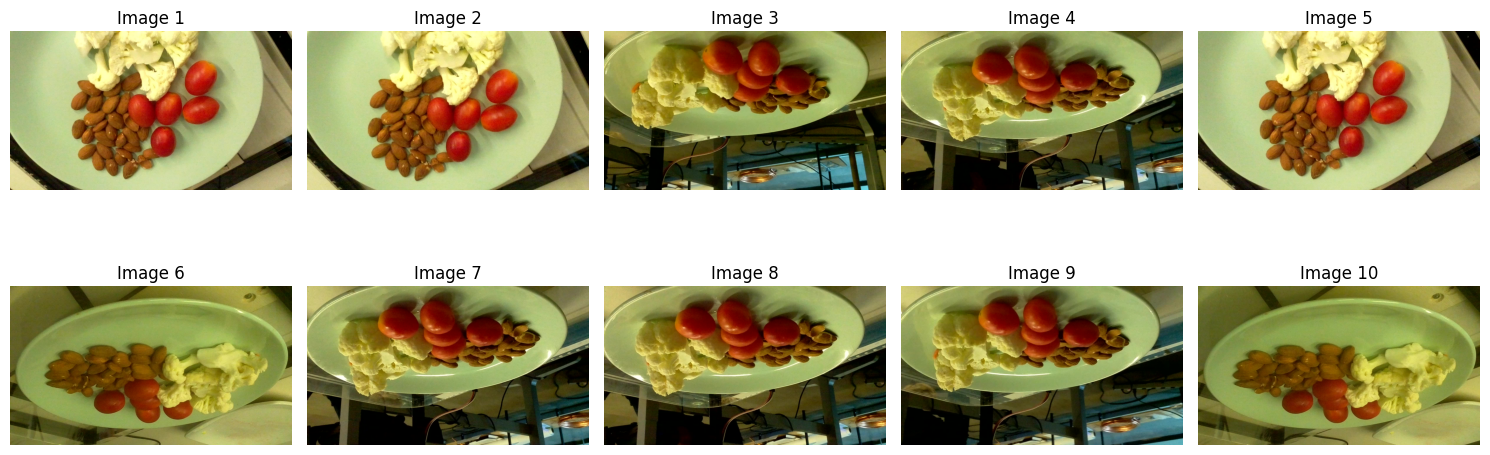

In [25]:
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(15, 6))

for i, img_path in enumerate(image_files[:10]):
    img = Image.open(img_path).convert("RGB")
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Image {i+1}")

plt.tight_layout()
plt.show()

The first 10 images loaded successfully from the Nutrition5k dataset. These images appear to show the same dish from multiple camera angles, which suggests that each dish may have several image views. This is useful because the model can learn from different visual perspectives, but we need to be careful when splitting the dataset so images of the same dish do not appear in both the training and testing sets.

In [26]:
import os

for root, dirs, files in os.walk("/content/nutrition5k"):
    level = root.replace("/content/nutrition5k", "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = " " * 4 * (level + 1)
    for file in files[:5]:
        print(f"{subindent}{file}")

    if level > 3:
        dirs[:] = []

Streaming output truncated to the last 5000 lines.
            dish_1563566674/
                depth_color.png
                rgb.png
                depth_raw.png
            dish_1559841781/
                depth_color.png
                rgb.png
                depth_raw.png
            dish_1563481030/
                depth_color.png
                rgb.png
                depth_raw.png
            dish_1562945879/
                depth_color.png
                rgb.png
                depth_raw.png
            dish_1564082462/
                depth_color.png
                rgb.png
                depth_raw.png
            dish_1567625343/
                depth_color.png
                rgb.png
                depth_raw.png
            dish_1564000202/
                depth_color.png
                rgb.png
                depth_raw.png
            dish_1566934152/
                depth_color.png
                rgb.png
                depth_raw.png
            dish_1566414924/


In [27]:
import os

for root, dirs, files in os.walk("/content/nutrition5k"):
    for file in files:
        if file.lower().endswith((".csv", ".json", ".txt")):
            print(os.path.join(root, file))

/content/nutrition5k/dish_ingredients.csv
/content/nutrition5k/dish_nutrition_values.csv
/content/nutrition5k/ingredients_metadata.csv


In [28]:
import pandas as pd

nutrition_path = "/content/nutrition5k/dish_nutrition_values.csv"

nutrition_df = pd.read_csv(nutrition_path)
nutrition_df.head()

,dish_id,calories,mass,fat,carb,protein
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970
1,dish_1562688426,137.569992,88.0,8.256000,5.190000,10.297000
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593
3,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387
4,dish_1560455030,20.590000,103.0,0.148000,4.625000,0.956000


In [29]:
import os

LOCAL_DATA_DIR = "/content/nutrition5k"

for root, dirs, files in os.walk(LOCAL_DATA_DIR):
    if "rgb.png" in files:
        print(root)
        break

/content/nutrition5k/imagery/realsense_overhead/dish_1558629517


In [30]:
IMAGE_ROOT = "/content/nutrition5k/imagery/realsense_overhead"

In [31]:
import os

def get_rgb_path(dish_id):
    return os.path.join(IMAGE_ROOT, dish_id, "rgb.png")

nutrition_df["image_path"] = nutrition_df["dish_id"].apply(get_rgb_path)
nutrition_df["image_exists"] = nutrition_df["image_path"].apply(os.path.exists)

nutrition_df["image_exists"].value_counts()

,count
image_exists,
True,3244
False,1524


# Nutrition-Based Calorie Prediction Baseline

Before building the image-based CNN model, we are first creating a nutrition-only baseline model. This model uses structured nutrition features from the Nutrition5k dataset, including mass, fat, carbohydrates, and protein, to predict total calories.

This baseline is important because calories are strongly related to macronutrients. By training this simpler model first, we can understand how well calorie prediction works using known nutrition information before attempting the harder computer vision task of predicting calories from food images.

## Goal of This Section

The goal of this section is to train a regression model that predicts calories using:

- mass
- fat
- carbohydrates
- protein

The target variable is:

- calories

We will evaluate the model using MAE, RMSE, and R².

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

features = ["mass", "fat", "carb", "protein"]
target = "calories"

clean_df = nutrition_df.dropna(subset=features + [target])

X = clean_df[features]
y = clean_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 13.073811337274165
RMSE: 25.402036366261196
R²: 0.9951447591233498


## Linear Regression Baseline Results

The nutrition-only Linear Regression baseline performed very well. The model had a Mean Absolute Error of about 13 calories, meaning its predictions were off by about 13 calories on average. The RMSE was about 25 calories, showing that some predictions had larger errors, but overall the model was still accurate.

The R² score was 0.995, meaning the model explained about 99.5% of the variation in calorie values. This high score makes sense because calories are strongly related to macronutrients such as fat, carbohydrates, and protein. This baseline gives us a strong comparison point before moving to the harder image-based CNN model.

In [33]:
coefficients = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_
})

coefficients

,feature,coefficient
0,mass,0.000870
1,fat,8.510610
2,carb,3.175374
3,protein,4.330243


## Coefficient Interpretation

The Linear Regression coefficients show that fat, carbohydrates, and protein are the strongest predictors of calories. This matches the standard nutrition formula, where fat contributes about 9 calories per gram, while carbohydrates and protein contribute about 4 calories per gram.

Our model learned a similar pattern: fat had the largest coefficient, followed by protein and carbohydrates. The mass coefficient was very close to zero, which suggests that food weight alone does not add much predictive value after the macronutrients are included. This confirms that the nutrition-only baseline is learning a meaningful relationship from the structured nutrition data.

In [34]:
clean_df = clean_df.copy()

clean_df["formula_calories"] = (
    9 * clean_df["fat"] +
    4 * clean_df["carb"] +
    4 * clean_df["protein"]
)

formula_mae = mean_absolute_error(clean_df["calories"], clean_df["formula_calories"])
formula_rmse = np.sqrt(mean_squared_error(clean_df["calories"], clean_df["formula_calories"]))
formula_r2 = r2_score(clean_df["calories"], clean_df["formula_calories"])

print("Formula Baseline Results")
print("MAE:", formula_mae)
print("RMSE:", formula_rmse)
print("R²:", formula_r2)

Formula Baseline Results
MAE: 13.096082962248321
RMSE: 44.00690726521819
R²: 0.9801755790690291


## Formula Baseline Comparison

We compared the Linear Regression model against the standard nutrition calorie formula:

Calories ≈ 9 × fat + 4 × carbohydrates + 4 × protein

The formula baseline performed well, with an MAE of about 13 calories and an R² score of 0.980. This confirms that calories are strongly tied to macronutrients. However, the Linear Regression model performed slightly better overall, especially in RMSE and R². The Linear Regression model had a lower RMSE, meaning it made fewer large errors, and it explained about 99.5% of the variation in calories.

This comparison shows that the learned model is able to adjust the calorie relationship slightly better for this dataset than the general nutrition formula.

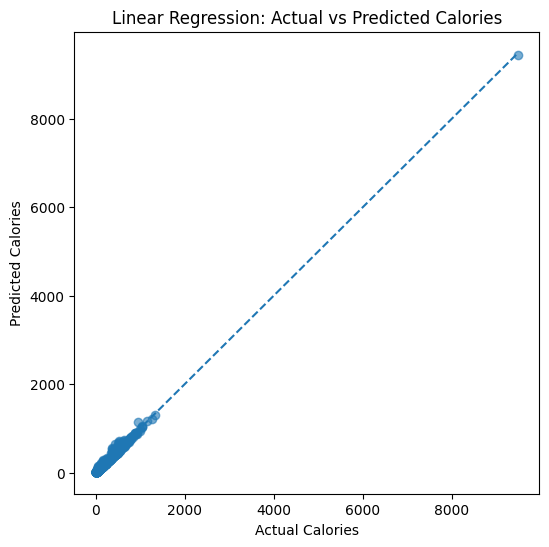

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.6)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Linear Regression: Actual vs Predicted Calories")

min_val = min(y_test.min(), preds.min())
max_val = max(y_test.max(), preds.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.show()

## Actual vs Predicted Calories

The actual vs predicted plot shows that the Linear Regression model performs very well overall. Most points fall close to the diagonal line, meaning the predicted calorie values are close to the actual calorie values. This supports the strong R² score of 0.995.

However, the plot also shows a large outlier with a calorie value above 9,000. This outlier stretches the graph and may affect the error metrics, especially RMSE. We should investigate this row to determine whether it represents a real dish, a data entry issue, or an unusually large serving.

In [36]:
 clean_df.sort_values(by="calories", ascending=False).head(10)

,dish_id,calories,mass,fat,carb,protein,image_path,image_exists,formula_calories
565,dish_1551567604,9485.815430,159.0,875.541016,506.079010,87.785004,/content/nutrition5k/imagery/realsense_overhea...,False,10255.325200
446,dish_1551567573,9485.815430,159.0,875.541016,506.078979,87.785004,/content/nutrition5k/imagery/realsense_overhea...,False,10255.325076
3568,dish_1551567508,9170.099609,7974.0,853.218018,502.362000,63.792004,/content/nutrition5k/imagery/realsense_overhea...,False,9943.578178
2213,dish_1560974769,3943.325195,3051.0,10.976549,844.568604,83.749603,/content/nutrition5k/imagery/realsense_overhea...,True,3812.061769
2334,dish_1551389551,2400.780029,133.0,27.552002,732.300049,90.181999,/content/nutrition5k/imagery/realsense_overhea...,False,3537.896210
995,dish_1551389588,2400.780029,133.0,27.552002,732.300049,90.181999,/content/nutrition5k/imagery/realsense_overhea...,False,3537.896210
4218,dish_1551389458,2312.459961,7974.0,23.922001,717.660034,87.713997,/content/nutrition5k/imagery/realsense_overhea...,False,3436.794133
192,dish_1565033265,1324.084961,625.0,106.343002,19.202002,76.664001,/content/nutrition5k/imagery/realsense_overhea...,True,1340.551030
4038,dish_1562603895,1268.157349,517.0,90.776642,68.637192,46.984001,/content/nutrition5k/imagery/realsense_overhea...,True,1279.474550
1657,dish_1564170010,1264.548340,831.0,61.893875,57.291939,116.862572,/content/nutrition5k/imagery/realsense_overhea...,True,1253.662919


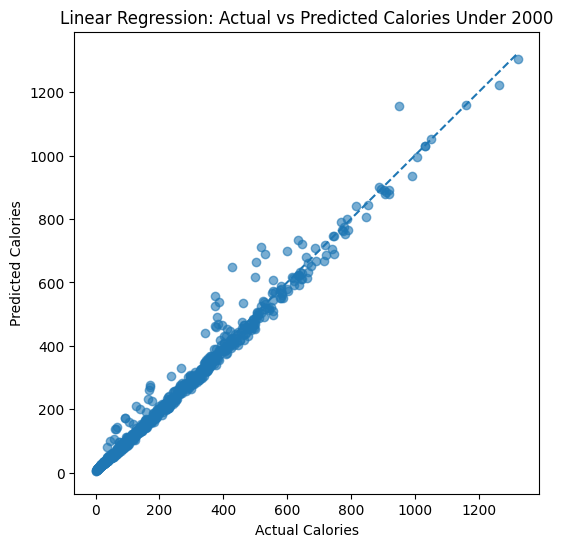

In [37]:
filtered_results = pd.DataFrame({
    "actual": y_test,
    "predicted": preds
})

filtered_results = filtered_results[filtered_results["actual"] < 2000]

plt.figure(figsize=(6, 6))
plt.scatter(filtered_results["actual"], filtered_results["predicted"], alpha=0.6)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Linear Regression: Actual vs Predicted Calories Under 2000")

min_val = min(filtered_results["actual"].min(), filtered_results["predicted"].min())
max_val = max(filtered_results["actual"].max(), filtered_results["predicted"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.show()

In [38]:
image_matched_df = nutrition_df[
    (nutrition_df["image_exists"] == True)
].copy()

image_matched_df.shape

(3244, 8)

In [39]:
image_matched_df.sort_values(by="calories", ascending=False).head(10)

,dish_id,calories,mass,fat,carb,protein,image_path,image_exists
2213,dish_1560974769,3943.325195,3051.0,10.976549,844.568604,83.749603,/content/nutrition5k/imagery/realsense_overhea...,True
192,dish_1565033265,1324.084961,625.0,106.343002,19.202002,76.664001,/content/nutrition5k/imagery/realsense_overhea...,True
4038,dish_1562603895,1268.157349,517.0,90.776642,68.637192,46.984001,/content/nutrition5k/imagery/realsense_overhea...,True
1657,dish_1564170010,1264.548340,831.0,61.893875,57.291939,116.862572,/content/nutrition5k/imagery/realsense_overhea...,True
2852,dish_1563476577,1238.033691,857.0,62.574154,79.601250,87.671616,/content/nutrition5k/imagery/realsense_overhea...,True
4154,dish_1563305083,1234.856323,901.0,56.759739,32.056351,147.491821,/content/nutrition5k/imagery/realsense_overhea...,True
3866,dish_1568401090,1158.989990,614.0,73.225998,18.445999,108.667999,/content/nutrition5k/imagery/realsense_overhea...,True
2077,dish_1558379876,1148.250977,374.0,89.766998,32.146000,68.292000,/content/nutrition5k/imagery/realsense_overhea...,True
4457,dish_1568318480,1119.280029,587.0,67.208000,9.174999,117.905998,/content/nutrition5k/imagery/realsense_overhea...,True
20,dish_1563476551,1116.391113,750.0,51.413692,74.705963,85.498482,/content/nutrition5k/imagery/realsense_overhea...,True


In [40]:
image_matched_df["calories"].describe()

,calories
count,3244.000000
mean,255.774014
std,219.642807
min,0.000000
25%,81.119995
50%,210.316384
75%,375.460839
max,3943.325195


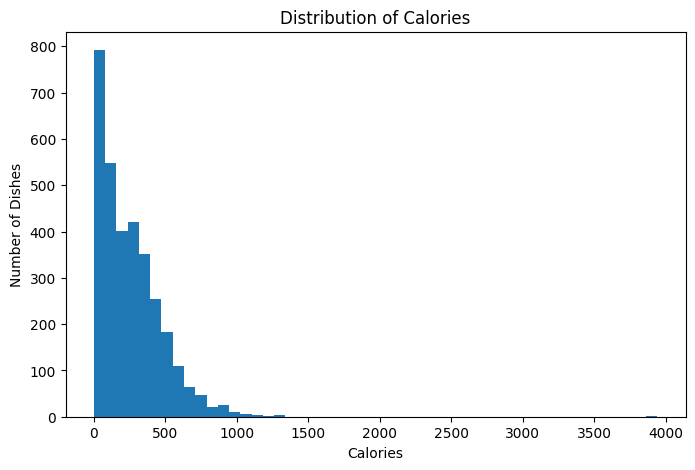

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(image_matched_df["calories"], bins=50)
plt.xlabel("Calories")
plt.ylabel("Number of Dishes")
plt.title("Distribution of Calories")
plt.show()

## Outlier and Image-Matching Review

During exploration, we found several high-calorie dishes in the dataset. Instead of removing all meals above a specific calorie threshold, we decided to keep high-calorie examples as long as they have valid image files and complete nutrition labels. This avoids deleting real meals just because they are calorie-dense.

For the first cleaned version of the dataset, we only removed rows that could not be used for our image-based project, such as rows without matching RGB images or rows with missing nutrition values. High-calorie meals were kept so the model can learn from a wider range of meal sizes and nutrition profiles.

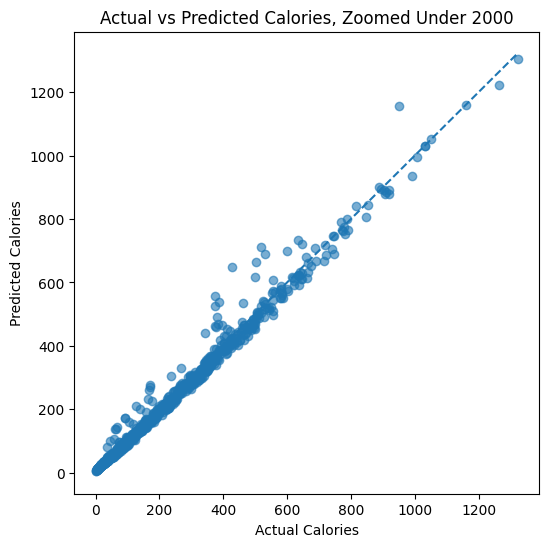

In [42]:
results_df = pd.DataFrame({
    "actual": y_test,
    "predicted": preds
})

zoom_df = results_df[results_df["actual"] <= 2000]

plt.figure(figsize=(6, 6))
plt.scatter(zoom_df["actual"], zoom_df["predicted"], alpha=0.6)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted Calories, Zoomed Under 2000")

min_val = min(zoom_df["actual"].min(), zoom_df["predicted"].min())
max_val = max(zoom_df["actual"].max(), zoom_df["predicted"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.show()

## Zoomed Actual vs Predicted Plot

Because the full plot included a few high-calorie outliers, we also created a zoomed-in plot for meals under 2,000 calories. This does not remove those higher-calorie meals from the dataset; it simply makes the main cluster easier to see.

The zoomed plot shows that most predictions fall close to the diagonal line, meaning the Linear Regression model is accurately predicting calories for most meals. The model performs especially well for lower- and medium-calorie dishes, while some higher-calorie meals show slightly more prediction error. Overall, this confirms that the structured nutrition features provide a strong baseline for calorie prediction.

# Image-Based Calorie Classification with a CNN

After building a nutrition-only baseline model, we are now starting the image-based part of the project. The goal of this section is to train a custom Convolutional Neural Network using the RGB food images from Nutrition5k.

Because predicting exact calories from images is difficult, we will first simplify the task into classification. Instead of predicting an exact calorie number, the CNN will predict whether a meal belongs to a low, medium, or high calorie range.

## Why We Are Using Calorie Classes

Our first fixed calorie ranges created a major class imbalance, with many more low-calorie meals than high-calorie meals. To make the CNN easier to train and evaluate fairly, we will use quantile-based calorie classes. This splits the dataset into three groups with roughly equal numbers of examples: low, medium, and high relative to the dataset.

In [43]:
%whos DataFrame

Variable           Type         Data/Info
-----------------------------------------
X                  DataFrame           mass        fat   <...>\n[4768 rows x 4 columns]
X_test             DataFrame           mass        fat   <...>n\n[954 rows x 4 columns]
X_train            DataFrame           mass        fat   <...>\n[3814 rows x 4 columns]
clean_df           DataFrame                  dish_id    <...>\n[4768 rows x 9 columns]
coefficients       DataFrame       feature  coefficient\n<...>\n3  protein     4.330243
filtered_results   DataFrame              actual   predic<...>n\n[953 rows x 2 columns]
image_matched_df   DataFrame                  dish_id    <...>\n[3244 rows x 8 columns]
nutrition_df       DataFrame                  dish_id    <...>\n[4768 rows x 8 columns]
results_df         DataFrame              actual   predic<...>n\n[954 rows x 2 columns]
zoom_df            DataFrame              actual   predic<...>n\n[953 rows x 2 columns]


In [44]:
import pandas as pd

clean_model_df = image_matched_df.copy()

clean_model_df["calorie_quantile_class"] = pd.qcut(
    clean_model_df["calories"],
    q=3,
    labels=[0, 1, 2]
).astype(int)

quantile_class_names = {
    0: "Low",
    1: "Medium",
    2: "High"
}

clean_model_df["calorie_quantile_label"] = clean_model_df["calorie_quantile_class"].map(quantile_class_names)

clean_model_df.head()

,dish_id,calories,mass,fat,carb,protein,image_path,image_exists,calorie_quantile_class,calorie_quantile_label
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970,/content/nutrition5k/imagery/realsense_overhea...,True,1,Medium
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593,/content/nutrition5k/imagery/realsense_overhea...,True,2,High
3,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387,/content/nutrition5k/imagery/realsense_overhea...,True,2,High
4,dish_1560455030,20.590000,103.0,0.148000,4.625000,0.956000,/content/nutrition5k/imagery/realsense_overhea...,True,0,Low
5,dish_1558372433,74.360001,143.0,0.286000,0.429000,20.020000,/content/nutrition5k/imagery/realsense_overhea...,True,0,Low


In [45]:
clean_model_df.columns

Index(['dish_id', 'calories', 'mass', 'fat', 'carb', 'protein', 'image_path',
       'image_exists', 'calorie_quantile_class', 'calorie_quantile_label'],
      dtype='object')

In [46]:
clean_model_df.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/nutrition5k_project/clean_model_df.csv",
    index=False
)

In [47]:
clean_model_df["calorie_quantile_label"].value_counts()

,count
calorie_quantile_label,
High,1082
Medium,1081
Low,1081


# Preparing Image Data for the CNN

Now that we have created balanced calorie classes, the next step is preparing the RGB food images for a custom CNN. We will use the image path as the input and the quantile-based calorie class as the target label.

In [48]:
clean_model_df.to_csv(
    "/content/drive/MyDrive/Colab Notebooks/nutrition5k_project/clean_model_df.csv",
    index=False
)

## Data Augmentation

We will apply light data augmentation only to the training images. This helps the CNN generalize better by showing it slightly different versions of the same type of food image.

The training images may be randomly flipped horizontally, slightly rotated, or adjusted in brightness and contrast. These changes are realistic for food photos and should not change the calorie label. We did not apply augmentation to the validation or test sets because those sets should remain fixed for fair evaluation.

In [49]:
from sklearn.model_selection import train_test_split

cnn_df = clean_model_df.dropna(
    subset=["image_path", "calorie_quantile_class"]
).copy()

cnn_df["calorie_quantile_class"] = cnn_df["calorie_quantile_class"].astype(int)

train_df, temp_df = train_test_split(
    cnn_df,
    test_size=0.30,
    random_state=42,
    stratify=cnn_df["calorie_quantile_class"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["calorie_quantile_class"]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain class balance:")
print(train_df["calorie_quantile_label"].value_counts())

print("\nValidation class balance:")
print(val_df["calorie_quantile_label"].value_counts())

print("\nTest class balance:")
print(test_df["calorie_quantile_label"].value_counts())

Train: (2270, 10)
Validation: (487, 10)
Test: (487, 10)

Train class balance:
calorie_quantile_label
Medium    757
High      757
Low       756
Name: count, dtype: int64

Validation class balance:
calorie_quantile_label
High      163
Low       162
Medium    162
Name: count, dtype: int64

Test class balance:
calorie_quantile_label
Low       163
Medium    162
High      162
Name: count, dtype: int64


In [50]:
PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/nutrition5k_project"

train_df.to_csv(f"{PROJECT_DIR}/train_df.csv", index=False)
val_df.to_csv(f"{PROJECT_DIR}/val_df.csv", index=False)
test_df.to_csv(f"{PROJECT_DIR}/test_df.csv", index=False)

In [51]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class NutritionImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.loc[idx, "image_path"]
        label = int(self.df.loc[idx, "calorie_quantile_class"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

We started with 128 × 128 images to reduce memory usage and training time while building the first CNN pipeline. Some fine visual details may be lost at this resolution, especially small ingredients or sauces. After confirming that the model trains correctly, we can compare performance with 224 × 224 images to test whether the extra visual detail improves calorie classification accuracy.

In [52]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    transforms.ToTensor()
])

eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [53]:
train_dataset = NutritionImageDataset(train_df, transform=train_transform)
val_dataset = NutritionImageDataset(val_df, transform=eval_transform)
test_dataset = NutritionImageDataset(test_df, transform=eval_transform)

In [54]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [55]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 128, 128])
Label batch shape: torch.Size([32])
First 10 labels: tensor([2, 1, 1, 2, 2, 1, 2, 1, 1, 0])


In [56]:
import torch.nn as nn
import torch.nn.functional as F

class FoodCalorieCNN(nn.Module):
    def __init__(self):
        super(FoodCalorieCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 128 -> 64
        x = self.pool(F.relu(self.conv2(x)))  # 64 -> 32
        x = self.pool(F.relu(self.conv3(x)))  # 32 -> 16

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [57]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = FoodCalorieCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Using device: cuda


In [58]:
epochs = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f}, "
        f"Train Acc: {train_accuracy:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch [1/10] Train Loss: 0.9850, Train Acc: 0.5079, Val Loss: 0.9297, Val Acc: 0.5749
Epoch [2/10] Train Loss: 0.9030, Train Acc: 0.5718, Val Loss: 0.8612, Val Acc: 0.6181
Epoch [3/10] Train Loss: 0.8358, Train Acc: 0.6150, Val Loss: 0.8495, Val Acc: 0.6160
Epoch [4/10] Train Loss: 0.7880, Train Acc: 0.6392, Val Loss: 0.8018, Val Acc: 0.6386
Epoch [5/10] Train Loss: 0.7663, Train Acc: 0.6507, Val Loss: 0.8343, Val Acc: 0.6263
Epoch [6/10] Train Loss: 0.7505, Train Acc: 0.6590, Val Loss: 0.7091, Val Acc: 0.6797
Epoch [7/10] Train Loss: 0.7094, Train Acc: 0.6753, Val Loss: 0.7100, Val Acc: 0.6694
Epoch [8/10] Train Loss: 0.6943, Train Acc: 0.6731, Val Loss: 0.6796, Val Acc: 0.7002
Epoch [9/10] Train Loss: 0.6796, Train Acc: 0.6952, Val Loss: 0.7063, Val Acc: 0.6756
Epoch [10/10] Train Loss: 0.6928, Train Acc: 0.6797, Val Loss: 0.6729, Val Acc: 0.7043


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
model.eval()

test_correct = 0
test_total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = test_correct / test_total

print("Test Accuracy:", test_accuracy)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

class_names = ["Low", "Medium", "High"]

print(classification_report(all_labels, all_preds, target_names=class_names))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/nutrition5k_project/food_calorie_cnn.pth"

torch.save(model.state_dict(), MODEL_PATH)

print("Model saved to:", MODEL_PATH)

## CNN Results

The custom CNN achieved a test accuracy of about 65.9% on the balanced low, medium, and high calorie classification task. Since the classes were balanced using quantile-based labels, random guessing would be expected to achieve about 33% accuracy. This shows that the CNN learned meaningful visual patterns from the food images.

The model performed best on the Low and High calorie classes, with F1-scores of 0.74 and 0.75. This suggests that the model was better at identifying meals near the lower and higher ends of the calorie distribution. The Medium class was the most difficult, with an F1-score of 0.41. This is expected because medium-calorie meals can visually overlap with both low- and high-calorie meals.

The confusion matrix shows that many Medium meals were predicted as High. However, the model rarely confused High-calorie meals with Low-calorie meals, which suggests that it learned a useful separation between the extreme classes.

Overall, the CNN performs significantly better than random guessing, but the results also show the limitations of using images alone for calorie estimation. Visual appearance can help identify general calorie ranges, but exact calorie content is difficult to infer from images because ingredients, sauces, density, and portion weight are not always visible.

Because the 128 × 128 CNN showed meaningful learning, we next tested whether increasing image resolution to 224 × 224 improves performance. The goal is to see whether preserving more visual detail helps the model better distinguish medium-calorie meals from low- and high-calorie meals.

In [ ]:
train_transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    transforms.ToTensor()
])

eval_transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [ ]:
train_dataset_224 = NutritionImageDataset(train_df, transform=train_transform_224)
val_dataset_224 = NutritionImageDataset(val_df, transform=eval_transform_224)
test_dataset_224 = NutritionImageDataset(test_df, transform=eval_transform_224)

train_loader_224 = DataLoader(train_dataset_224, batch_size=32, shuffle=True)
val_loader_224 = DataLoader(val_dataset_224, batch_size=32, shuffle=False)
test_loader_224 = DataLoader(test_dataset_224, batch_size=32, shuffle=False)

In [67]:
images, labels = next(iter(train_loader_224))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [68]:
class FoodCalorieCNN224(nn.Module):
    def __init__(self):
        super(FoodCalorieCNN224, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 224 -> 112
        x = self.pool(F.relu(self.conv2(x)))  # 112 -> 56
        x = self.pool(F.relu(self.conv3(x)))  # 56 -> 28

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [69]:
model_224 = FoodCalorieCNN224().to(device)

criterion = nn.CrossEntropyLoss()
optimizer_224 = torch.optim.Adam(model_224.parameters(), lr=0.001)

In [70]:
epochs = 10

train_losses_224 = []
val_losses_224 = []
train_accuracies_224 = []
val_accuracies_224 = []

for epoch in range(epochs):
    model_224.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_224:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_224.zero_grad()

        outputs = model_224(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer_224.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader_224)
    train_accuracy = correct / total

    model_224.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader_224:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model_224(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader_224)
    val_accuracy = val_correct / val_total

    train_losses_224.append(train_loss)
    val_losses_224.append(val_loss)
    train_accuracies_224.append(train_accuracy)
    val_accuracies_224.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f}, "
        f"Train Acc: {train_accuracy:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch [1/10] Train Loss: 1.0661, Train Acc: 0.4238, Val Loss: 0.9419, Val Acc: 0.5667
Epoch [2/10] Train Loss: 0.9017, Train Acc: 0.5590, Val Loss: 0.8932, Val Acc: 0.5811
Epoch [3/10] Train Loss: 0.8499, Train Acc: 0.6119, Val Loss: 0.8055, Val Acc: 0.6304
Epoch [4/10] Train Loss: 0.7947, Train Acc: 0.6238, Val Loss: 0.7941, Val Acc: 0.6099
Epoch [5/10] Train Loss: 0.7656, Train Acc: 0.6348, Val Loss: 0.7680, Val Acc: 0.6283
Epoch [6/10] Train Loss: 0.7197, Train Acc: 0.6731, Val Loss: 0.6982, Val Acc: 0.6489
Epoch [7/10] Train Loss: 0.7053, Train Acc: 0.6815, Val Loss: 0.6790, Val Acc: 0.6715
Epoch [8/10] Train Loss: 0.6743, Train Acc: 0.6912, Val Loss: 0.7267, Val Acc: 0.6694
Epoch [9/10] Train Loss: 0.6647, Train Acc: 0.6982, Val Loss: 0.7213, Val Acc: 0.6899
Epoch [10/10] Train Loss: 0.6334, Train Acc: 0.7128, Val Loss: 0.6777, Val Acc: 0.6982


In [71]:
model_224.eval()

test_correct = 0
test_total = 0

all_preds_224 = []
all_labels_224 = []

with torch.no_grad():
    for images, labels in test_loader_224:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_224(images)
        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        all_preds_224.extend(predicted.cpu().numpy())
        all_labels_224.extend(labels.cpu().numpy())

test_accuracy_224 = test_correct / test_total

print("224 × 224 Test Accuracy:", test_accuracy_224)

224 × 224 Test Accuracy: 0.6694045174537988


In [72]:
from sklearn.metrics import classification_report, confusion_matrix

class_names = ["Low", "Medium", "High"]

print(classification_report(
    all_labels_224,
    all_preds_224,
    target_names=class_names
))

              precision    recall  f1-score   support

         Low       0.80      0.66      0.72       163
      Medium       0.55      0.44      0.49       162
        High       0.66      0.91      0.76       162

    accuracy                           0.67       487
   macro avg       0.67      0.67      0.66       487
weighted avg       0.67      0.67      0.66       487



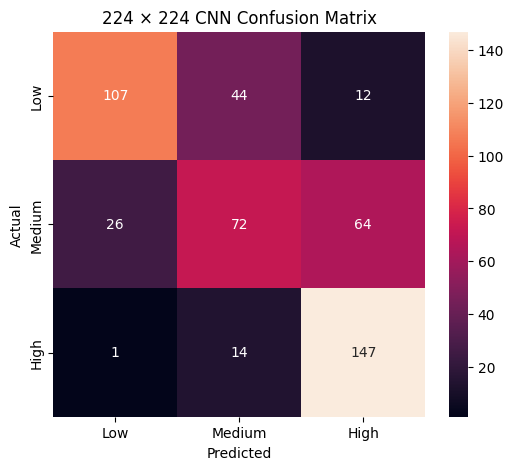

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_224 = confusion_matrix(all_labels_224, all_preds_224)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_224,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("224 × 224 CNN Confusion Matrix")
plt.show()

## 224 × 224 CNN Results

The 224 × 224 CNN achieved a test accuracy of 66.9%, which was slightly higher than the 128 × 128 CNN accuracy of 65.9%. This suggests that increasing the image resolution helped the model preserve more visual detail, but the improvement was modest.

The biggest improvement came from the Medium calorie class. In the 128 × 128 model, the Medium class had an F1-score of 0.41. In the 224 × 224 model, the Medium F1-score improved to 0.49. This shows that the larger image size helped the model better distinguish middle-range calorie meals.

The confusion matrix shows that the model still often confused Medium meals with High meals, but this error decreased compared to the 128 × 128 model. The model continued to perform best on the Low and High classes, which suggests that the visual differences between the extreme calorie ranges are easier for the CNN to learn.

Overall, the 224 × 224 model performed slightly better than the 128 × 128 model, especially for the Medium class. However, the improvement was not large, showing that image resolution alone does not fully solve the difficulty of estimating calories from food images.

# Experiment 3: Multi-Task CNN with 224 × 224 Images

The previous image-only CNN used food images to classify meals as Low, Medium, or High calorie. In this experiment, we use multi-task learning to give the CNN extra supervision during training.

The model still takes only an image as input. However, during training it learns to predict both the calorie class and related nutrition values, including calories, mass, fat, carbohydrates, and protein.

At inference time, the model can still be used with only a food image. The nutrition values are not required as input.

In [74]:
multitask_df = clean_model_df.dropna(
    subset=[
        "image_path",
        "calorie_quantile_class",
        "calories",
        "mass",
        "fat",
        "carb",
        "protein"
    ]
).copy()

multitask_df["calorie_quantile_class"] = multitask_df["calorie_quantile_class"].astype(int)

print(multitask_df.shape)
print(multitask_df["calorie_quantile_label"].value_counts())

(3244, 10)
calorie_quantile_label
High      1082
Medium    1081
Low       1081
Name: count, dtype: int64


In [75]:
from sklearn.model_selection import train_test_split

train_df_mt, temp_df_mt = train_test_split(
    multitask_df,
    test_size=0.30,
    random_state=42,
    stratify=multitask_df["calorie_quantile_class"]
)

val_df_mt, test_df_mt = train_test_split(
    temp_df_mt,
    test_size=0.50,
    random_state=42,
    stratify=temp_df_mt["calorie_quantile_class"]
)

print("Train:", train_df_mt.shape)
print("Validation:", val_df_mt.shape)
print("Test:", test_df_mt.shape)

print("\nTrain class balance:")
print(train_df_mt["calorie_quantile_label"].value_counts())

Train: (2270, 10)
Validation: (487, 10)
Test: (487, 10)

Train class balance:
calorie_quantile_label
Medium    757
High      757
Low       756
Name: count, dtype: int64


In [76]:
from sklearn.preprocessing import StandardScaler

regression_targets = ["calories", "mass", "fat", "carb", "protein"]

scaler = StandardScaler()

train_df_mt_scaled = train_df_mt.copy()
val_df_mt_scaled = val_df_mt.copy()
test_df_mt_scaled = test_df_mt.copy()

train_df_mt_scaled[regression_targets] = scaler.fit_transform(
    train_df_mt[regression_targets]
)

val_df_mt_scaled[regression_targets] = scaler.transform(
    val_df_mt[regression_targets]
)

test_df_mt_scaled[regression_targets] = scaler.transform(
    test_df_mt[regression_targets]
)

In [77]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class NutritionMultiTaskDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.loc[idx, "image_path"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        class_label = int(self.df.loc[idx, "calorie_quantile_class"])

        regression_values = self.df.loc[
            idx,
            ["calories", "mass", "fat", "carb", "protein"]
        ].values.astype("float32")

        regression_values = torch.tensor(regression_values, dtype=torch.float32)

        return image, class_label, regression_values

In [78]:
from torchvision import transforms

train_transform_mt = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    transforms.ToTensor()
])

eval_transform_mt = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [79]:
train_dataset_mt = NutritionMultiTaskDataset(
    train_df_mt_scaled,
    transform=train_transform_mt
)

val_dataset_mt = NutritionMultiTaskDataset(
    val_df_mt_scaled,
    transform=eval_transform_mt
)

test_dataset_mt = NutritionMultiTaskDataset(
    test_df_mt_scaled,
    transform=eval_transform_mt
)

train_loader_mt = DataLoader(
    train_dataset_mt,
    batch_size=32,
    shuffle=True
)

val_loader_mt = DataLoader(
    val_dataset_mt,
    batch_size=32,
    shuffle=False
)

test_loader_mt = DataLoader(
    test_dataset_mt,
    batch_size=32,
    shuffle=False
)

In [80]:
images, class_labels, regression_values = next(iter(train_loader_mt))

print("Images:", images.shape)
print("Class labels:", class_labels.shape)
print("Regression values:", regression_values.shape)
print("First class labels:", class_labels[:10])
print("First regression row:", regression_values[0])

Images: torch.Size([32, 3, 224, 224])
Class labels: torch.Size([32])
Regression values: torch.Size([32, 5])
First class labels: tensor([1, 0, 0, 0, 1, 2, 2, 1, 1, 1])
First regression row: tensor([-0.3929, -0.2377, -0.2501,  0.0809, -0.8303])


In [81]:
import torch.nn as nn
import torch.nn.functional as F

class MultiTaskFoodCNN224(nn.Module):
    def __init__(self):
        super(MultiTaskFoodCNN224, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # 224 -> 112 -> 56 -> 28 after three pooling layers
        self.shared_fc = nn.Linear(64 * 28 * 28, 128)
        self.dropout = nn.Dropout(0.3)

        # Main task: Low / Medium / High calorie class
        self.class_head = nn.Linear(128, 3)

        # Auxiliary task: calories, mass, fat, carb, protein
        self.regression_head = nn.Linear(128, 5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 224 -> 112
        x = self.pool(F.relu(self.conv2(x)))  # 112 -> 56
        x = self.pool(F.relu(self.conv3(x)))  # 56 -> 28

        x = x.view(x.size(0), -1)

        features = F.relu(self.shared_fc(x))
        features = self.dropout(features)

        class_output = self.class_head(features)
        regression_output = self.regression_head(features)

        return class_output, regression_output

In [82]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model_mt = MultiTaskFoodCNN224().to(device)

classification_loss_fn = nn.CrossEntropyLoss()
regression_loss_fn = nn.MSELoss()

optimizer_mt = torch.optim.Adam(model_mt.parameters(), lr=0.001)

Using device: cuda


In [83]:
epochs = 10

regression_loss_weight = 0.3

train_losses_mt = []
val_losses_mt = []
train_accuracies_mt = []
val_accuracies_mt = []

for epoch in range(epochs):
    model_mt.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, class_labels, regression_values in train_loader_mt:
        images = images.to(device)
        class_labels = class_labels.to(device)
        regression_values = regression_values.to(device)

        optimizer_mt.zero_grad()

        class_outputs, regression_outputs = model_mt(images)

        class_loss = classification_loss_fn(class_outputs, class_labels)
        reg_loss = regression_loss_fn(regression_outputs, regression_values)

        loss = class_loss + regression_loss_weight * reg_loss

        loss.backward()
        optimizer_mt.step()

        running_loss += loss.item()

        _, predicted = torch.max(class_outputs, 1)
        total += class_labels.size(0)
        correct += (predicted == class_labels).sum().item()

    train_loss = running_loss / len(train_loader_mt)
    train_accuracy = correct / total

    model_mt.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, class_labels, regression_values in val_loader_mt:
            images = images.to(device)
            class_labels = class_labels.to(device)
            regression_values = regression_values.to(device)

            class_outputs, regression_outputs = model_mt(images)

            class_loss = classification_loss_fn(class_outputs, class_labels)
            reg_loss = regression_loss_fn(regression_outputs, regression_values)

            loss = class_loss + regression_loss_weight * reg_loss

            val_running_loss += loss.item()

            _, predicted = torch.max(class_outputs, 1)
            val_total += class_labels.size(0)
            val_correct += (predicted == class_labels).sum().item()

    val_loss = val_running_loss / len(val_loader_mt)
    val_accuracy = val_correct / val_total

    train_losses_mt.append(train_loss)
    val_losses_mt.append(val_loss)
    train_accuracies_mt.append(train_accuracy)
    val_accuracies_mt.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f}, "
        f"Train Acc: {train_accuracy:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch [1/10] Train Loss: 1.2972, Train Acc: 0.5035, Val Loss: 1.1052, Val Acc: 0.5852
Epoch [2/10] Train Loss: 1.0923, Train Acc: 0.5859, Val Loss: 0.9943, Val Acc: 0.6366
Epoch [3/10] Train Loss: 0.9754, Train Acc: 0.6410, Val Loss: 0.9134, Val Acc: 0.6242
Epoch [4/10] Train Loss: 0.9552, Train Acc: 0.6551, Val Loss: 0.8374, Val Acc: 0.6899
Epoch [5/10] Train Loss: 0.9085, Train Acc: 0.6696, Val Loss: 0.8114, Val Acc: 0.7023
Epoch [6/10] Train Loss: 0.8784, Train Acc: 0.6824, Val Loss: 0.9509, Val Acc: 0.6674
Epoch [7/10] Train Loss: 0.8461, Train Acc: 0.7000, Val Loss: 0.7784, Val Acc: 0.7166
Epoch [8/10] Train Loss: 0.8188, Train Acc: 0.7119, Val Loss: 0.7673, Val Acc: 0.7187
Epoch [9/10] Train Loss: 0.7993, Train Acc: 0.7238, Val Loss: 0.7749, Val Acc: 0.7146
Epoch [10/10] Train Loss: 0.7763, Train Acc: 0.7291, Val Loss: 0.7368, Val Acc: 0.7248


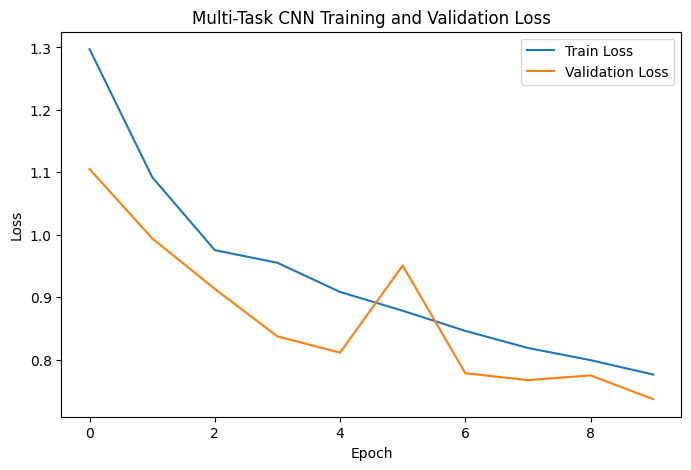

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses_mt, label="Train Loss")
plt.plot(val_losses_mt, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Multi-Task CNN Training and Validation Loss")
plt.legend()
plt.show()

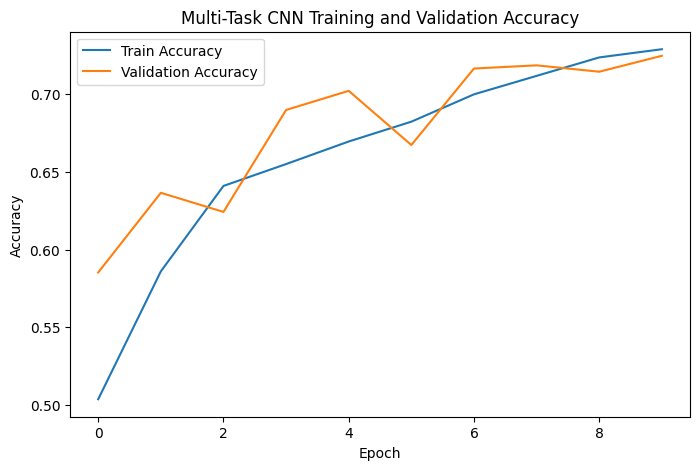

In [85]:
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies_mt, label="Train Accuracy")
plt.plot(val_accuracies_mt, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Multi-Task CNN Training and Validation Accuracy")
plt.legend()
plt.show()

In [86]:
model_mt.eval()

all_preds_mt = []
all_labels_mt = []

with torch.no_grad():
    for images, class_labels, regression_values in test_loader_mt:
        images = images.to(device)
        class_labels = class_labels.to(device)

        class_outputs, regression_outputs = model_mt(images)

        _, predicted = torch.max(class_outputs, 1)

        all_preds_mt.extend(predicted.cpu().numpy())
        all_labels_mt.extend(class_labels.cpu().numpy())

test_accuracy_mt = sum(
    pred == label for pred, label in zip(all_preds_mt, all_labels_mt)
) / len(all_labels_mt)

print("Multi-Task CNN Test Accuracy:", test_accuracy_mt)

Multi-Task CNN Test Accuracy: 0.7002053388090349


In [87]:
from sklearn.metrics import classification_report, confusion_matrix

class_names = ["Low", "Medium", "High"]

print(classification_report(
    all_labels_mt,
    all_preds_mt,
    target_names=class_names
))

              precision    recall  f1-score   support

         Low       0.80      0.70      0.75       163
      Medium       0.57      0.53      0.55       162
        High       0.73      0.87      0.80       162

    accuracy                           0.70       487
   macro avg       0.70      0.70      0.70       487
weighted avg       0.70      0.70      0.70       487



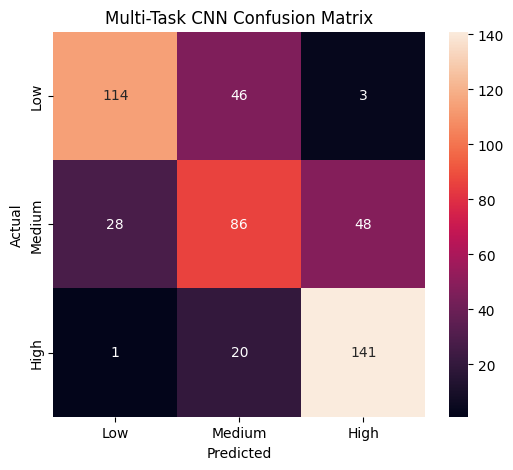

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_mt = confusion_matrix(all_labels_mt, all_preds_mt)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_mt,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multi-Task CNN Confusion Matrix")
plt.show()

In [89]:
MODEL_PATH_MT = "/content/drive/MyDrive/Colab Notebooks/nutrition5k_project/multitask_food_calorie_cnn_224.pth"

torch.save(model_mt.state_dict(), MODEL_PATH_MT)

print("Multi-task model saved to:", MODEL_PATH_MT)

Multi-task model saved to: /content/drive/MyDrive/Colab Notebooks/nutrition5k_project/multitask_food_calorie_cnn_224.pth


In [90]:
print("128 × 128 Image-Only CNN Accuracy: 0.6591")
print("224 × 224 Image-Only CNN Accuracy:", test_accuracy_224)
print("224 × 224 Multi-Task CNN Accuracy:", test_accuracy_mt)

128 × 128 Image-Only CNN Accuracy: 0.6591
224 × 224 Image-Only CNN Accuracy: 0.6694045174537988
224 × 224 Multi-Task CNN Accuracy: 0.7002053388090349


## Multi-Task CNN Results

The 224 × 224 multi-task CNN achieved a test accuracy of 70.0%, which was higher than both image-only CNN models. The 128 × 128 image-only CNN achieved 65.9% accuracy, while the 224 × 224 image-only CNN achieved 66.9% accuracy. This shows that multi-task learning provided the strongest performance improvement.

The main benefit appeared in the Medium calorie class. The Medium F1-score improved from 0.41 in the 128 × 128 CNN to 0.49 in the 224 × 224 CNN, and then to 0.55 in the multi-task CNN. This is important because Medium was the hardest class for the image-only models. Medium-calorie meals can visually overlap with both Low and High meals, making them difficult to classify from images alone.

The confusion matrix shows that the multi-task CNN reduced the number of Medium meals incorrectly predicted as High. In the 224 × 224 image-only CNN, 64 Medium meals were predicted as High. In the multi-task CNN, this decreased to 48. This suggests that the extra nutrition supervision helped the model learn more useful image features.

Overall, the multi-task CNN performed best because it used nutrition values as auxiliary training targets while still requiring only an image as input. This supports the idea that nutrition information can improve image-based calorie classification during training, even when nutrition values are not available during inference.

## Training for Additional Epochs

After training the 224 × 224 multi-task CNN for 10 epochs, the model showed continued improvement without strong signs of overfitting. By the final epoch, the training accuracy was 72.9% and the validation accuracy was 72.5%, meaning the model was performing similarly on both the training and validation sets.

Because the validation accuracy was still improving and stayed close to the training accuracy, we decided to train the model for additional epochs. The goal was to give the CNN more time to learn useful image features while monitoring whether the validation performance continued to improve.

Instead of simply using the final epoch, we used validation checkpointing. This means the model is saved whenever it achieves a new best validation accuracy. This approach helps prevent overfitting because the final model is selected based on validation performance, not just the last training epoch.

This choice is important because additional training can improve accuracy, but too many epochs can cause the model to memorize the training data. By saving the best validation model, we can continue training while still keeping the version that generalizes best to unseen data.

In [91]:
epochs = 20
regression_loss_weight = 0.3

best_val_accuracy = 0.0
best_model_path = "/content/drive/MyDrive/Colab Notebooks/nutrition5k_project/best_multitask_food_calorie_cnn_224.pth"

train_losses_mt = []
val_losses_mt = []
train_accuracies_mt = []
val_accuracies_mt = []

for epoch in range(epochs):
    model_mt.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, class_labels, regression_values in train_loader_mt:
        images = images.to(device)
        class_labels = class_labels.to(device)
        regression_values = regression_values.to(device)

        optimizer_mt.zero_grad()

        class_outputs, regression_outputs = model_mt(images)

        class_loss = classification_loss_fn(class_outputs, class_labels)
        reg_loss = regression_loss_fn(regression_outputs, regression_values)

        loss = class_loss + regression_loss_weight * reg_loss

        loss.backward()
        optimizer_mt.step()

        running_loss += loss.item()

        _, predicted = torch.max(class_outputs, 1)
        total += class_labels.size(0)
        correct += (predicted == class_labels).sum().item()

    train_loss = running_loss / len(train_loader_mt)
    train_accuracy = correct / total

    model_mt.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, class_labels, regression_values in val_loader_mt:
            images = images.to(device)
            class_labels = class_labels.to(device)
            regression_values = regression_values.to(device)

            class_outputs, regression_outputs = model_mt(images)

            class_loss = classification_loss_fn(class_outputs, class_labels)
            reg_loss = regression_loss_fn(regression_outputs, regression_values)

            loss = class_loss + regression_loss_weight * reg_loss

            val_running_loss += loss.item()

            _, predicted = torch.max(class_outputs, 1)
            val_total += class_labels.size(0)
            val_correct += (predicted == class_labels).sum().item()

    val_loss = val_running_loss / len(val_loader_mt)
    val_accuracy = val_correct / val_total

    train_losses_mt.append(train_loss)
    val_losses_mt.append(val_loss)
    train_accuracies_mt.append(train_accuracy)
    val_accuracies_mt.append(val_accuracy)

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model_mt.state_dict(), best_model_path)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f}, "
        f"Train Acc: {train_accuracy:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Acc: {val_accuracy:.4f}, "
        f"Best Val Acc: {best_val_accuracy:.4f}"
    )

Epoch [1/20] Train Loss: 0.7926, Train Acc: 0.7203, Val Loss: 0.7637, Val Acc: 0.7228, Best Val Acc: 0.7228
Epoch [2/20] Train Loss: 0.7608, Train Acc: 0.7449, Val Loss: 0.7286, Val Acc: 0.7248, Best Val Acc: 0.7248
Epoch [3/20] Train Loss: 0.7513, Train Acc: 0.7344, Val Loss: 0.7572, Val Acc: 0.7105, Best Val Acc: 0.7248
Epoch [4/20] Train Loss: 0.7487, Train Acc: 0.7454, Val Loss: 0.8098, Val Acc: 0.6797, Best Val Acc: 0.7248
Epoch [5/20] Train Loss: 0.7485, Train Acc: 0.7379, Val Loss: 0.7090, Val Acc: 0.7495, Best Val Acc: 0.7495
Epoch [6/20] Train Loss: 0.7152, Train Acc: 0.7555, Val Loss: 0.7062, Val Acc: 0.7556, Best Val Acc: 0.7556
Epoch [7/20] Train Loss: 0.7202, Train Acc: 0.7533, Val Loss: 0.6957, Val Acc: 0.7495, Best Val Acc: 0.7556
Epoch [8/20] Train Loss: 0.6822, Train Acc: 0.7753, Val Loss: 0.6887, Val Acc: 0.7515, Best Val Acc: 0.7556
Epoch [9/20] Train Loss: 0.6859, Train Acc: 0.7687, Val Loss: 0.7477, Val Acc: 0.7331, Best Val Acc: 0.7556
Epoch [10/20] Train Loss: 0.

In [92]:
model_mt.load_state_dict(torch.load(best_model_path))
model_mt.eval()

MultiTaskFoodCNN224(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (shared_fc): Linear(in_features=50176, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (class_head): Linear(in_features=128, out_features=3, bias=True)
  (regression_head): Linear(in_features=128, out_features=5, bias=True)
)

In [93]:
best_model_path = "/content/drive/MyDrive/Colab Notebooks/nutrition5k_project/best_multitask_food_calorie_cnn_224.pth"

model_mt.load_state_dict(torch.load(best_model_path))
model_mt.eval()

MultiTaskFoodCNN224(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (shared_fc): Linear(in_features=50176, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (class_head): Linear(in_features=128, out_features=3, bias=True)
  (regression_head): Linear(in_features=128, out_features=5, bias=True)
)

In [94]:
model_mt.eval()

all_preds_mt_best = []
all_labels_mt_best = []

with torch.no_grad():
    for images, class_labels, regression_values in test_loader_mt:
        images = images.to(device)
        class_labels = class_labels.to(device)

        class_outputs, regression_outputs = model_mt(images)

        _, predicted = torch.max(class_outputs, 1)

        all_preds_mt_best.extend(predicted.cpu().numpy())
        all_labels_mt_best.extend(class_labels.cpu().numpy())

test_accuracy_mt_best = sum(
    pred == label for pred, label in zip(all_preds_mt_best, all_labels_mt_best)
) / len(all_labels_mt_best)

print("Best Checkpoint Multi-Task CNN Test Accuracy:", test_accuracy_mt_best)

Best Checkpoint Multi-Task CNN Test Accuracy: 0.7125256673511293


In [95]:
from sklearn.metrics import classification_report, confusion_matrix

class_names = ["Low", "Medium", "High"]

print(classification_report(
    all_labels_mt_best,
    all_preds_mt_best,
    target_names=class_names
))

              precision    recall  f1-score   support

         Low       0.77      0.81      0.79       163
      Medium       0.58      0.58      0.58       162
        High       0.78      0.75      0.76       162

    accuracy                           0.71       487
   macro avg       0.71      0.71      0.71       487
weighted avg       0.71      0.71      0.71       487



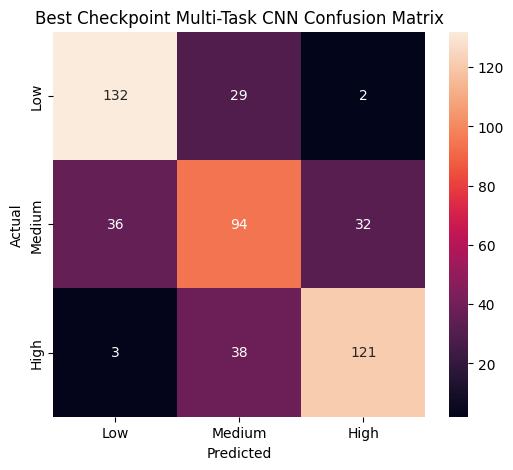

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_mt_best = confusion_matrix(all_labels_mt_best, all_preds_mt_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_mt_best,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Best Checkpoint Multi-Task CNN Confusion Matrix")
plt.show()

## Best Checkpoint Multi-Task CNN Results

The best checkpoint multi-task CNN achieved the strongest image-based performance, with a test accuracy of 71.3%. This was higher than the 128 × 128 image-only CNN, the 224 × 224 image-only CNN, and the original 10-epoch multi-task CNN.

The final model also produced the most balanced class performance. The Low class achieved an F1-score of 0.79, the Medium class achieved an F1-score of 0.58, and the High class achieved an F1-score of 0.76. The Medium class remained the most difficult, but it improved noticeably compared to the earlier image-only CNN models.

This improvement supports the use of multi-task learning. The model still only takes an image as input, but during training it also learns to predict related nutrition values such as calories, mass, fat, carbohydrates, and protein. These auxiliary targets likely helped the CNN learn more useful visual features related to portion size, food density, and meal composition.

The confusion matrix shows that the final model correctly classified 132 Low meals, 94 Medium meals, and 121 High meals. Compared to earlier models, the best checkpoint model made more balanced predictions and reduced the tendency to over-predict the High class.

Overall, the best checkpoint multi-task CNN is the strongest deployable model in this project because it achieves the highest image-based test accuracy while still requiring only a food image at inference time.

# Multi-Task Loss Weight Tuning

The best multi-task CNN so far used a regression loss weight of 0.3. This weight controls how much the auxiliary nutrition prediction task affects training.

In this section, we test different regression loss weights to see whether the model performs better when it focuses more or less on the auxiliary nutrition targets. The model still takes only an image as input, but the nutrition values are used during training as extra supervision.

In [97]:
import torch
from sklearn.metrics import classification_report, confusion_matrix

def train_multitask_model_with_weight(weight, epochs=20):
    print(f"\nTraining multi-task CNN with regression_loss_weight = {weight}\n")

    model = MultiTaskFoodCNN224().to(device)

    classification_loss_fn = nn.CrossEntropyLoss()
    regression_loss_fn = nn.MSELoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_val_accuracy = 0.0
    best_model_path = f"/content/drive/MyDrive/Colab Notebooks/nutrition5k_project/best_multitask_weight_{weight}.pth"

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, class_labels, regression_values in train_loader_mt:
            images = images.to(device)
            class_labels = class_labels.to(device)
            regression_values = regression_values.to(device)

            optimizer.zero_grad()

            class_outputs, regression_outputs = model(images)

            class_loss = classification_loss_fn(class_outputs, class_labels)
            reg_loss = regression_loss_fn(regression_outputs, regression_values)

            loss = class_loss + weight * reg_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(class_outputs, 1)
            total += class_labels.size(0)
            correct += (predicted == class_labels).sum().item()

        train_loss = running_loss / len(train_loader_mt)
        train_accuracy = correct / total

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, class_labels, regression_values in val_loader_mt:
                images = images.to(device)
                class_labels = class_labels.to(device)
                regression_values = regression_values.to(device)

                class_outputs, regression_outputs = model(images)

                class_loss = classification_loss_fn(class_outputs, class_labels)
                reg_loss = regression_loss_fn(regression_outputs, regression_values)

                loss = class_loss + weight * reg_loss

                val_running_loss += loss.item()

                _, predicted = torch.max(class_outputs, 1)
                val_total += class_labels.size(0)
                val_correct += (predicted == class_labels).sum().item()

        val_loss = val_running_loss / len(val_loader_mt)
        val_accuracy = val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), best_model_path)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f}, "
            f"Train Acc: {train_accuracy:.4f}, "
            f"Val Loss: {val_loss:.4f}, "
            f"Val Acc: {val_accuracy:.4f}, "
            f"Best Val Acc: {best_val_accuracy:.4f}"
        )

    return model, best_model_path, best_val_accuracy, train_losses, val_losses, train_accuracies, val_accuracies

In [98]:
def evaluate_multitask_checkpoint(model, best_model_path):
    model.load_state_dict(torch.load(best_model_path))
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, class_labels, regression_values in test_loader_mt:
            images = images.to(device)
            class_labels = class_labels.to(device)

            class_outputs, regression_outputs = model(images)

            _, predicted = torch.max(class_outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(class_labels.cpu().numpy())

    test_accuracy = sum(
        pred == label for pred, label in zip(all_preds, all_labels)
    ) / len(all_labels)

    class_names = ["Low", "Medium", "High"]

    print("Test Accuracy:", test_accuracy)
    print(classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    ))

    cm = confusion_matrix(all_labels, all_preds)

    return test_accuracy, all_labels, all_preds, cm

In [99]:
model_w01, path_w01, best_val_w01, train_losses_w01, val_losses_w01, train_acc_w01, val_acc_w01 = train_multitask_model_with_weight(
    weight=0.1,
    epochs=20
)


Training multi-task CNN with regression_loss_weight = 0.1

Epoch [1/20] Train Loss: 1.1209, Train Acc: 0.4863, Val Loss: 1.0522, Val Acc: 0.5626, Best Val Acc: 0.5626
Epoch [2/20] Train Loss: 0.9757, Train Acc: 0.5758, Val Loss: 0.9547, Val Acc: 0.5832, Best Val Acc: 0.5832
Epoch [3/20] Train Loss: 0.9453, Train Acc: 0.5855, Val Loss: 0.9114, Val Acc: 0.6119, Best Val Acc: 0.6119
Epoch [4/20] Train Loss: 0.9029, Train Acc: 0.6115, Val Loss: 0.8597, Val Acc: 0.6489, Best Val Acc: 0.6489
Epoch [5/20] Train Loss: 0.8762, Train Acc: 0.6269, Val Loss: 0.8607, Val Acc: 0.6386, Best Val Acc: 0.6489
Epoch [6/20] Train Loss: 0.8542, Train Acc: 0.6370, Val Loss: 0.7672, Val Acc: 0.6776, Best Val Acc: 0.6776
Epoch [7/20] Train Loss: 0.7958, Train Acc: 0.6639, Val Loss: 0.7458, Val Acc: 0.6715, Best Val Acc: 0.6776
Epoch [8/20] Train Loss: 0.7800, Train Acc: 0.6692, Val Loss: 0.7470, Val Acc: 0.7064, Best Val Acc: 0.7064
Epoch [9/20] Train Loss: 0.7679, Train Acc: 0.6784, Val Loss: 0.7094, Val Ac

In [100]:
test_acc_w01, labels_w01, preds_w01, cm_w01 = evaluate_multitask_checkpoint(
    model_w01,
    path_w01
)

Test Accuracy: 0.7145790554414785
              precision    recall  f1-score   support

         Low       0.76      0.77      0.76       163
      Medium       0.59      0.56      0.58       162
        High       0.78      0.81      0.80       162

    accuracy                           0.71       487
   macro avg       0.71      0.71      0.71       487
weighted avg       0.71      0.71      0.71       487



In [101]:
model_w05, path_w05, best_val_w05, train_losses_w05, val_losses_w05, train_acc_w05, val_acc_w05 = train_multitask_model_with_weight(
    weight=0.5,
    epochs=20
)


Training multi-task CNN with regression_loss_weight = 0.5

Epoch [1/20] Train Loss: 1.3979, Train Acc: 0.5004, Val Loss: 1.1475, Val Acc: 0.6283, Best Val Acc: 0.6283
Epoch [2/20] Train Loss: 1.2008, Train Acc: 0.6097, Val Loss: 1.0318, Val Acc: 0.6571, Best Val Acc: 0.6571
Epoch [3/20] Train Loss: 1.1196, Train Acc: 0.6419, Val Loss: 0.9767, Val Acc: 0.6674, Best Val Acc: 0.6674
Epoch [4/20] Train Loss: 1.0706, Train Acc: 0.6489, Val Loss: 0.9655, Val Acc: 0.6489, Best Val Acc: 0.6674
Epoch [5/20] Train Loss: 1.0230, Train Acc: 0.6784, Val Loss: 0.9139, Val Acc: 0.6858, Best Val Acc: 0.6858
Epoch [6/20] Train Loss: 1.0124, Train Acc: 0.6793, Val Loss: 0.8856, Val Acc: 0.7084, Best Val Acc: 0.7084
Epoch [7/20] Train Loss: 1.0054, Train Acc: 0.6811, Val Loss: 0.8481, Val Acc: 0.7187, Best Val Acc: 0.7187
Epoch [8/20] Train Loss: 0.9650, Train Acc: 0.7084, Val Loss: 0.9311, Val Acc: 0.6776, Best Val Acc: 0.7187
Epoch [9/20] Train Loss: 0.9457, Train Acc: 0.7079, Val Loss: 0.8394, Val Ac

In [102]:
test_acc_w05, labels_w05, preds_w05, cm_w05 = evaluate_multitask_checkpoint(
    model_w05,
    path_w05
)

Test Accuracy: 0.7227926078028748
              precision    recall  f1-score   support

         Low       0.78      0.82      0.80       163
      Medium       0.59      0.62      0.60       162
        High       0.81      0.73      0.77       162

    accuracy                           0.72       487
   macro avg       0.73      0.72      0.72       487
weighted avg       0.73      0.72      0.72       487



## Multi-Task Loss Weight Results

We tested different regression loss weights to determine how strongly the auxiliary nutrition prediction task should influence the multi-task CNN. The regression loss weight controls the balance between the main calorie classification task and the auxiliary regression task.

With a weight of 0.1, the model achieved 71.5% test accuracy. This was slightly better than the original 0.3 model, which achieved 71.3% test accuracy. Increasing the weight to 0.5 produced the best result so far, with a test accuracy of 72.3%.

The 0.5 model also improved the Medium calorie class, increasing the Medium F1-score to 0.60. This is important because the Medium class was the most difficult for earlier image-only models. The improvement suggests that the auxiliary nutrition targets helped the model learn visual features related to portion size, food density, and meal composition.

Overall, these results show that nutrition supervision helps the image-only model, but the strength of that supervision matters. A regression loss weight of 0.5 provided the best balance so far between calorie classification and nutrition prediction.

In [103]:
model_w10, path_w10, best_val_w10, train_losses_w10, val_losses_w10, train_acc_w10, val_acc_w10 = train_multitask_model_with_weight(
    weight=1.0,
    epochs=20
)


Training multi-task CNN with regression_loss_weight = 1.0

Epoch [1/20] Train Loss: 1.9596, Train Acc: 0.4630, Val Loss: 1.6065, Val Acc: 0.6078, Best Val Acc: 0.6078
Epoch [2/20] Train Loss: 1.6660, Train Acc: 0.5700, Val Loss: 1.5298, Val Acc: 0.5708, Best Val Acc: 0.6078
Epoch [3/20] Train Loss: 1.6006, Train Acc: 0.5978, Val Loss: 1.4113, Val Acc: 0.5955, Best Val Acc: 0.6078
Epoch [4/20] Train Loss: 1.5121, Train Acc: 0.6145, Val Loss: 1.3469, Val Acc: 0.6263, Best Val Acc: 0.6263
Epoch [5/20] Train Loss: 1.4290, Train Acc: 0.6366, Val Loss: 1.3221, Val Acc: 0.6550, Best Val Acc: 0.6550
Epoch [6/20] Train Loss: 1.3959, Train Acc: 0.6537, Val Loss: 1.2639, Val Acc: 0.6427, Best Val Acc: 0.6550
Epoch [7/20] Train Loss: 1.3538, Train Acc: 0.6736, Val Loss: 1.1619, Val Acc: 0.6879, Best Val Acc: 0.6879
Epoch [8/20] Train Loss: 1.3072, Train Acc: 0.6824, Val Loss: 1.1721, Val Acc: 0.7043, Best Val Acc: 0.7043
Epoch [9/20] Train Loss: 1.2994, Train Acc: 0.6877, Val Loss: 1.1490, Val Ac

In [104]:
test_acc_w10, labels_w10, preds_w10, cm_w10 = evaluate_multitask_checkpoint(
    model_w10,
    path_w10
)

Test Accuracy: 0.7227926078028748
              precision    recall  f1-score   support

         Low       0.79      0.74      0.76       163
      Medium       0.60      0.58      0.59       162
        High       0.77      0.85      0.81       162

    accuracy                           0.72       487
   macro avg       0.72      0.72      0.72       487
weighted avg       0.72      0.72      0.72       487



In [105]:
loss_weight_results = pd.DataFrame({
    "regression_loss_weight": [0.1, 0.3, 0.5, 1.0],
    "best_val_accuracy": [best_val_w01, 0.7618, best_val_w05, best_val_w10],
    "test_accuracy": [test_acc_w01, 0.7125, test_acc_w05, test_acc_w10]
})

loss_weight_results

,regression_loss_weight,best_val_accuracy,test_accuracy
0,0.1,0.747433,0.714579
1,0.3,0.761800,0.712500
2,0.5,0.751540,0.722793
3,1.0,0.743326,0.722793


## Multi-Task Loss Weight Tuning Results

We tested regression loss weights of 0.1, 0.3, 0.5, and 1.0 to determine how strongly the auxiliary nutrition prediction task should influence the multi-task CNN.

The original multi-task model used a regression loss weight of 0.3 and achieved 71.3% test accuracy. Lowering the weight to 0.1 slightly improved test accuracy to 71.5%, while increasing the weight to 0.5 improved test accuracy to 72.3%. A weight of 1.0 also achieved 72.3% test accuracy.

Although weights 0.5 and 1.0 tied in test accuracy, the 0.5 model had a slightly higher best validation accuracy. The 0.5 setting also provides a better balance between the main calorie classification task and the auxiliary nutrition regression task. For this reason, we selected the 0.5 model as the final model.

These results show that auxiliary nutrition supervision helped the image-only CNN. The best model still only requires an image at inference time, but during training it benefited from learning related targets such as calories, mass, fat, carbohydrates, and protein.